# 🚀 ResNet18 Transfer Learning

In the previous notebook, we discussed the theory and strategies of **Transfer Learning (TL)**. Today, we put that knowledge into practice.

### Goal
We will use a pre-trained **ResNet18** model (trained on the massive ImageNet dataset) and adapt it to classify images in the **CIFAR-10** dataset (10 classes: plane, car, bird, cat, deer, dog, frog, horse, ship, truck).

### Strategy: Fixed Feature Extractor
Since CIFAR-10 is a relatively small dataset (50,000 images) and visual data is highly relevant to ImageNet, we will use the **Fixed Feature Extractor** strategy:

1.  Load pre-trained ResNet18.
2.  **Freeze** all convolutional layers (the feature extraction backbone).
3.  **Replace** the final classification layer.
4.  **Train** *only* the new classification layer.

This dramatically reduces training time and prevents overfitting on our smaller dataset.

## 1. Setup and Configuration

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
NUM_CLASSES = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 10 # Small number of epochs since we're only training the head

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Data Loading with ImageNet Normalization

A critical step in using a pre-trained model is ensuring the input data is standardized the same way the model was originally trained. For ResNet18 (trained on ImageNet), we must use the **ImageNet Mean and Standard Deviation** for normalization.

CIFAR-10 images are $32 \times 32$, so we also **resize** them to the standard $224 \times 224$ expected by the ResNet architecture.

In [3]:
# ImageNet statistics for normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Data augmentation and normalization for training
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Just normalization for validation/testing
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Load CIFAR-10 data
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches: {len(test_loader)}")

Training batches: 782
Testing batches: 157


## 3. Model Configuration: ResNet18 Feature Extractor

We perform the critical steps of Transfer Learning: **loading pre-trained weights, freezing the backbone, and replacing the final layer.**

In [5]:
def setup_resnet18_extractor(num_classes):
    # 1. Load Pre-trained Model
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # 2. Freeze all parameters (The core feature extractor)
    print("Freezing all layers in the backbone...")
    for param in model.parameters():
        param.requires_grad = False

    # 3. Replace the Fully Connected Head (fc)
    num_ftrs = model.fc.in_features

    # We replace it with a new Linear layer that outputs NUM_CLASSES.
    # By default, this new layer's parameters have requires_grad=True.
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model

# Initialize the model
model = setup_resnet18_extractor(NUM_CLASSES).to(device)

# --- Sanity Check ---
# Check that only the final layer's weights are trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("\n--- Model Status ---")
print(f"Total Parameters: {total_params}")
print(f"Trainable Parameters (Head only): {trainable_params}")

Freezing all layers in the backbone...

--- Model Status ---
Total Parameters: 11181642
Trainable Parameters (Head only): 5130


## 4. Training Setup

Since we are only training the final layer, our optimization step will be incredibly fast. We use the standard **CrossEntropyLoss** for multi-class classification.

In [9]:
# Notice we pass ALL parameters to the optimizer, but only the UN-frozen ones
# (i.e., model.fc) will actually have gradients computed and updated.
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

print(f"Training for {NUM_EPOCHS} epochs with LR={LEARNING_RATE}")

Training for 10 epochs with LR=0.001


## 5. Training Loop

In [10]:
# --- Training Function ---
def train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS):
    model.train()
    history = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(True):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        history.append({'loss': epoch_loss, 'acc': epoch_acc.item()})
        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return model, history

# --- Execute Training ---
model_ft, history = train_model(model, criterion, optimizer)

print("\nTraining complete.")

Epoch 1/10 | Loss: 0.9383 Acc: 0.6901
Epoch 2/10 | Loss: 0.7266 Acc: 0.7527
Epoch 3/10 | Loss: 0.6953 Acc: 0.7609
Epoch 4/10 | Loss: 0.6863 Acc: 0.7622
Epoch 5/10 | Loss: 0.6796 Acc: 0.7639
Epoch 6/10 | Loss: 0.6731 Acc: 0.7663
Epoch 7/10 | Loss: 0.6642 Acc: 0.7691
Epoch 8/10 | Loss: 0.6645 Acc: 0.7688
Epoch 9/10 | Loss: 0.6607 Acc: 0.7720
Epoch 10/10 | Loss: 0.6564 Acc: 0.7712

Training complete.


## 6. Evaluation

We now check the performance on the test set. Due to the power of the pre-trained features, we should achieve good results even after training only the single final layer for a few epochs.

Test Accuracy (Fixed Feature Extractor): 77.73%


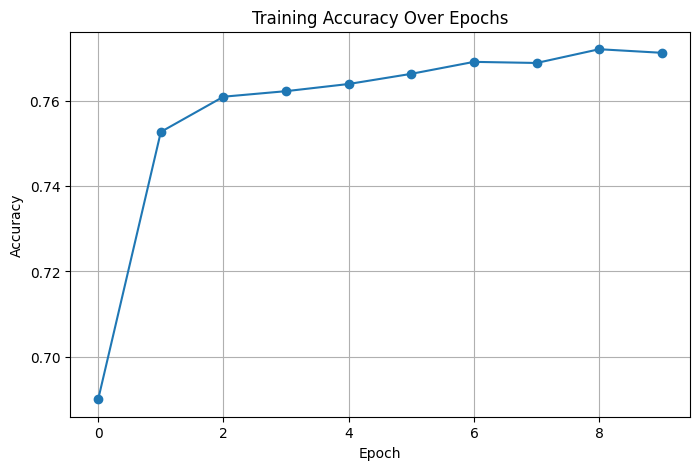

In [11]:
# --- Evaluation Function ---
def evaluate_model(model, loader):
    model.eval()
    corrects = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            corrects += torch.sum(preds == labels.data)

    accuracy = corrects.double() / total
    return accuracy.item()

# --- Run Evaluation ---
test_accuracy = evaluate_model(model_ft, test_loader)
print(f"Test Accuracy (Fixed Feature Extractor): {test_accuracy*100:.2f}%")

# --- Visualize Accuracy ---
plt.figure(figsize=(8, 5))
plt.plot([h['acc'] for h in history], marker='o')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## 7. Fine-Tuning (Unfreezing Backbone Layers)

Now, let's explore **Fine-Tuning**. This strategy is suitable when your target dataset is larger or somewhat different from the pre-training dataset.

Here, we will:
1.  **Unfreeze** the last convolutional block (`layer4`) of the ResNet18 backbone.
2.  Use a **much smaller learning rate** for fine-tuning to preserve the learned features.
3.  **Continue training** for a few more epochs, allowing the backbone to adapt slightly to the CIFAR-10 data while the new head further refines its weights.

In [12]:
# --- Configuration for Fine-Tuning ---
FINE_TUNE_LR = 0.00001 # A much smaller learning rate for fine-tuning
FINE_TUNE_EPOCHS = 5 # Train for a few more epochs

print(f"Fine-tuning with LR={FINE_TUNE_LR} for {FINE_TUNE_EPOCHS} epochs.")

# --- Unfreeze specific layers ---
# We'll unfreeze 'layer4' of the ResNet18 model.
# All other layers remain frozen (requires_grad=False).

print("Unfreezing layer4 for fine-tuning...")
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# --- Check trainable parameters again ---
trainable_params_finetune = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
print(f"Trainable Parameters (Head + Layer4): {trainable_params_finetune}")


Fine-tuning with LR=1e-05 for 5 epochs.
Unfreezing layer4 for fine-tuning...
Trainable Parameters (Head + Layer4): 8398858


In [13]:
# --- Re-initialize Optimizer for Fine-Tuning ---
# It's good practice to pass only the trainable parameters to the optimizer.
# Alternatively, you could use different learning rates for different parameter groups.
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model_ft.parameters()), lr=FINE_TUNE_LR)

print("Optimizer re-initialized for fine-tuning.")


Optimizer re-initialized for fine-tuning.


In [14]:
# --- Execute Fine-Tuning Training ---
print("Starting fine-tuning...")
model_fine_tuned, fine_tune_history = train_model(model_ft, criterion, optimizer_ft, num_epochs=FINE_TUNE_EPOCHS)

# Combine histories for plotting
combined_history = history + fine_tune_history

print("Fine-tuning complete.")


Starting fine-tuning...
Epoch 1/5 | Loss: 0.5476 Acc: 0.8116
Epoch 2/5 | Loss: 0.4332 Acc: 0.8482
Epoch 3/5 | Loss: 0.3755 Acc: 0.8695
Epoch 4/5 | Loss: 0.3373 Acc: 0.8817
Epoch 5/5 | Loss: 0.3060 Acc: 0.8943
Fine-tuning complete.



Test Accuracy (Fine-Tuned ResNet18): 87.89%


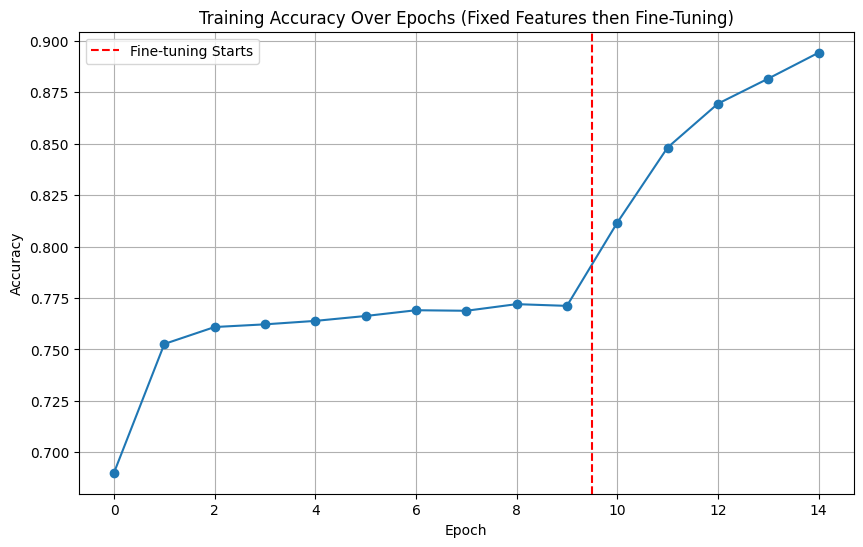

In [15]:
# --- Evaluate Fine-Tuned Model ---
fine_tune_test_accuracy = evaluate_model(model_fine_tuned, test_loader)
print(f"\nTest Accuracy (Fine-Tuned ResNet18): {fine_tune_test_accuracy*100:.2f}%")

# --- Visualize Combined Accuracy ---
plt.figure(figsize=(10, 6))
plt.plot([h['acc'] for h in combined_history], marker='o')
plt.axvline(x=len(history) - 0.5, color='r', linestyle='--', label='Fine-tuning Starts')
plt.title("Training Accuracy Over Epochs (Fixed Features then Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


## 8. Conclusion

This notebook demonstrated two powerful Transfer Learning strategies:

1.  **Fixed Feature Extractor**: Reused ResNet18 features, froze the backbone (\~11M parameters), and trained only the new $\text{fc}$ layer (\~5k parameters). Achieved good accuracy quickly.
2.  **Fine-Tuning**: Unfroze the last convolutional block (`layer4`) and continued training with a smaller learning rate. This allowed the model's feature extractor to adapt further to the CIFAR-10 dataset, potentially yielding even better performance.

The choice between these strategies depends on the target dataset size and its similarity to the pre-training dataset. Fine-tuning offers more flexibility but requires careful handling of learning rates and more computational resources.